In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad_vec
from field_kit import FourierAnalysis, GaussianRandomField, plaw_with_cutoffs

In [2]:
# Parameters for the Gaussian random fields
l_min = 10.0  # minimum or "dissipation" scale
l_max = 200.0  # maximum or "injection" scale
alpha = -11.0 / 3.0
f_rms = 10.0  # normalization of the field

In [3]:
# Make two power spectra with different l_min values
power_spec = plaw_with_cutoffs(l_min, l_max, alpha)

In [4]:
# Renormalize the power spectra to have the desired RMS value
power_spec.renormalize(f_rms)

In [5]:
# Parameters for the box and grid
le = np.array([0.0, 0.0, 0.0])
re = np.array([750.0, 750.0, 750.0])
ddims = [256] * 3
width = re - le

In [6]:
# This makes a Gaussian random field with the specified power spectrum
g = GaussianRandomField(le, re, ddims, power_spec, seed=10)
B = g.generate_vector_field_realization()

In [7]:
# This is a class I wrote to simplify stuff
fa = FourierAnalysis(width, ddims)

In [8]:
dkx = fa.kx[1, 0, 0] - fa.kx[0, 0, 0]
dky = fa.ky[0, 1, 0] - fa.ky[0, 0, 0]

In [9]:
kmin = 0.0001
kmax = 100.0  # a really big number to approximate infinity


def P1_int(k_perp, eta):
    k = np.sqrt(eta ** 2 + k_perp ** 2)
    term1 = power_spec(k)*k_perp/(2.0*np.pi)
    term2 = 0.5*(1 - 0.5 * (k_perp ** 2 / (k * k)))
    return term1 * term2


eta = fa.kx[128:, 0, 0]

P_1D = quad_vec(P1_int, kmin, kmax, args=(eta,), points=(0.1, 1.0, 10.0, 30.0))[0]


In [10]:
P_3D = fa.make_powerspec(B)
P_T = 0.5*(P_3D[1]+P_3D[2])
P_1Ds = (P_T*dkx*dky).sum(axis=(1, 2))/(2*np.pi)**2
P_1Ds = 0.5*(P_1Ds[128:]+P_1Ds[::-1][128:])

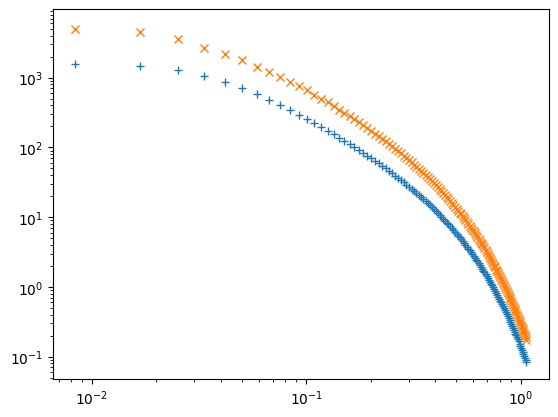

In [11]:
plt.loglog(eta, P_1D, '+', label="1D Power Spectrum")
plt.loglog(eta, P_1Ds, 'x')

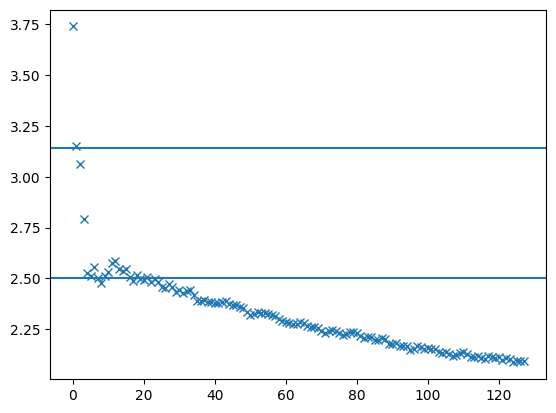

In [12]:
plt.plot(P_1Ds/P_1D, 'x')
plt.axhline(np.pi)
plt.axhline(2.5)
